In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
log_file_path = Path("/YAZILIM/Machine Learning/Deep Learnnig/RL/rl_atari/experiments/agent/replay_experimental_0/logs")
# files start with "metrics_ep"
log_files = list(log_file_path.glob("metrics_ep*.csv"))
log_files.sort(key=lambda x: int(x.stem.split("_")[2]))  # Sort by episode number
log_files

[WindowsPath('/YAZILIM/Machine Learning/Deep Learnnig/RL/rl_atari/experiments/agent/replay_experimental_0/logs/metrics_ep_50_opt_step_0_6784.csv'),
 WindowsPath('/YAZILIM/Machine Learning/Deep Learnnig/RL/rl_atari/experiments/agent/replay_experimental_0/logs/metrics_ep_100_opt_step_6784_13464.csv')]

In [14]:
# Load the CSV and merge them into a single DataFrame
df = pd.concat([pd.read_csv(file) for file in log_files], ignore_index=True)
df.head()

,optimization_step,global_step,episode,total_reward,total_loss,td_loss,kl_loss,total_dnd_inserts,total_dnd_updates
0,0,3894,1,-12.99068,4.170748,4.170748,0.0,368,0
1,1,3894,1,-12.99068,0.460936,0.460936,0.0,368,0
2,2,3894,1,-12.99068,0.462992,0.462992,0.0,368,0
3,3,3894,1,-12.99068,8.228553,8.228553,0.0,368,0
4,4,3894,1,-12.99068,6.835095,6.835095,0.0,368,0


In [18]:
inserts_updates = df[['global_step', 'episode', 'total_dnd_inserts', 'total_dnd_updates']].copy()
inserts_updates.drop_duplicates(inplace=True)
inserts_updates.reset_index(drop=True, inplace=True)
inserts_updates.head()

,global_step,episode,total_dnd_inserts,total_dnd_updates
0,3894,1,368,0
1,4615,2,547,1200
2,5432,3,643,4000
3,5963,4,357,2800
4,6656,5,519,5900


In [19]:
inserts_updates['global_step'].diff() 


0       NaN
1     721.0
2     817.0
3     531.0
4     693.0
      ...  
95    929.0
96    802.0
97    709.0
98    811.0
99    724.0
Name: global_step, Length: 100, dtype: float64

In [24]:
inserts_updates['transition_count'] = (inserts_updates['global_step'].diff() - 174).fillna(0).astype(int) 

In [25]:
inserts_updates.head()

,global_step,episode,total_dnd_inserts,total_dnd_updates,transition_count
0,3894,1,368,0,0
1,4615,2,547,1200,547
2,5432,3,643,4000,643
3,5963,4,357,2800,357
4,6656,5,519,5900,519


In [32]:
inserts_updates['insert_rate'] = np.divide(inserts_updates['total_dnd_inserts'], inserts_updates['transition_count'])    
inserts_updates.head()

,global_step,episode,total_dnd_inserts,total_dnd_updates,transition_count,insert_rate
0,3894,1,368,0,0,inf
1,4615,2,547,1200,547,1.0
2,5432,3,643,4000,643,1.0
3,5963,4,357,2800,357,1.0
4,6656,5,519,5900,519,1.0


Text(0.5, 1.0, 'Insert Rate Over Episodes')

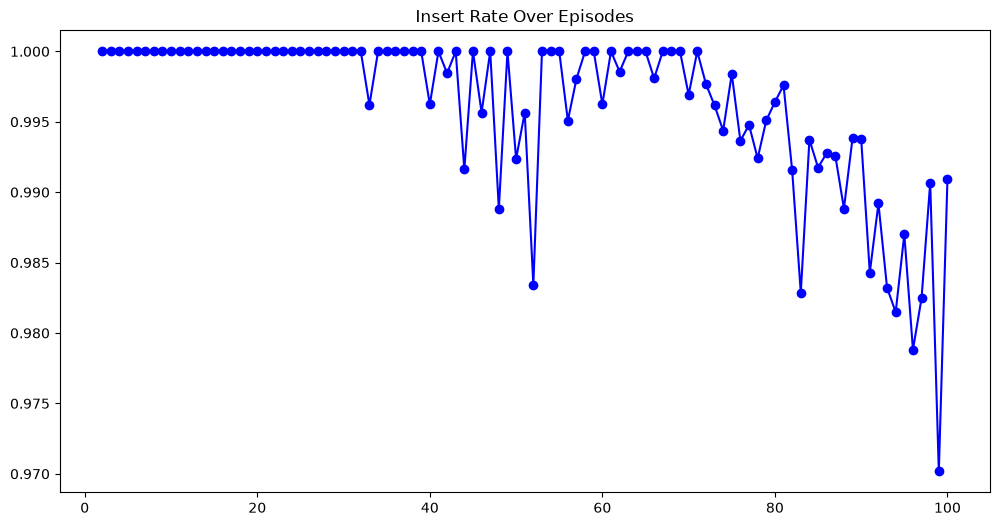

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(inserts_updates['episode'], inserts_updates['insert_rate'], marker='o', linestyle='-', color='b')
plt.title('Insert Rate Over Episodes')

In [29]:
inserts_updates

,global_step,episode,total_dnd_inserts,total_dnd_updates,transition_count,insert_rate
0,3894,1,368,0,0,0
1,4615,2,547,1200,547,1
2,5432,3,643,4000,643,1
3,5963,4,357,2800,357,1
4,6656,5,519,5900,519,1
...,...,...,...,...,...,...
95,71309,96,739,70316,755,0
96,72111,97,617,58511,628,0
97,72820,98,530,50405,535,0
98,73631,99,618,58119,637,0
